# ACO for CVRP — X-Series Analysis

Comparative analysis of Greedy, ACO, EAS, and MMAS on CVRPLIB X-series instances.

In [3]:
%matplotlib inline
import json, pathlib, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt

sys.path.insert(0, "..")
from src.viz import plot_routes, plot_convergence, plot_convergence_derivative, plot_boxplots, plot_scaling
from src.vrp import load_vrp, load_sol
from src.solution import compute_total_dist

MAIN_DIR   = pathlib.Path("../results/X")
SWEEP_DIR  = pathlib.Path("../results/sweep_X")
DATA_DIR   = pathlib.Path("../data/X")

df = pd.read_csv(MAIN_DIR / "results.csv")
df["feasible"] = df["feasible"].astype(bool)
df["relative_error"] = pd.to_numeric(df["relative_error"], errors="coerce")
df["s_max"] = pd.to_numeric(df["s_max"], errors="coerce")
main = df[df["feasible"] & df["s_max"].isna()]
print(f"Loaded {len(df)} runs, {len(main)} feasible unconstrained")

Loaded 180 runs, 0 feasible unconstrained


## H3.1 — Solution Quality

Mean relative error vs best-known across algorithms. Box plots show distribution across seeds.

In [4]:
print("=== Mean relative error vs best known ===")
display(
    main.groupby("algorithm")["relative_error"]
    .agg(["mean", "std", "min"])
    .round(4)
    .sort_values("mean")
)

print("\n=== Mean total distance per instance ===")
display(
    main.groupby(["algorithm", "instance"])["total_dist"]
    .mean().round(1).unstack("algorithm")
)

plot_boxplots(main)

# --- Route comparison from JSON ---
json_files = list(MAIN_DIR.glob("*.json"))
all_runs = {}
for jf in json_files:
    run = json.loads(jf.read_text())
    if not run.get("feasible") or not run.get("routes") or run.get("s_max") is not None:
        continue
    key = (run["instance"], run["algorithm"])
    if key not in all_runs or run["total_dist"] < all_runs[key]["total_dist"]:
        all_runs[key] = run

instances = sorted({k[0] for k in all_runs})
algos = ["greedy", "aco", "eas", "mmas"]

for inst_name in instances:
    sol_path = DATA_DIR / f"{inst_name}.sol"
    vrp_path = DATA_DIR / f"{inst_name}.vrp"
    if not sol_path.exists() or not vrp_path.exists():
        continue
    inst = load_vrp(str(vrp_path))
    optimal_routes, optimal_cost = load_sol(str(sol_path))

    available = [(a, all_runs[(inst_name, a)]) for a in algos if (inst_name, a) in all_runs]
    n_cols = 1 + len(available)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    plot_routes(optimal_routes, inst.coords, f"Optimal ({optimal_cost:.0f})", ax=axes[0])
    for i, (algo, run) in enumerate(available, 1):
        cost = run["total_dist"]
        re = (cost - optimal_cost) / optimal_cost * 100 if optimal_cost else 0
        plot_routes(run["routes"], inst.coords, f"{algo} ({cost:.0f}, +{re:.1f}%)", ax=axes[i])
    fig.suptitle(inst_name, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

=== Mean relative error vs best known ===


,mean,std,min
algorithm,,,



=== Mean total distance per instance ===


algorithm
instance


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x600 with 0 Axes>

## H3.2 — Scalability

Relative error and runtime vs instance size.

No feasible runs with known best solutions found for scaling plot.


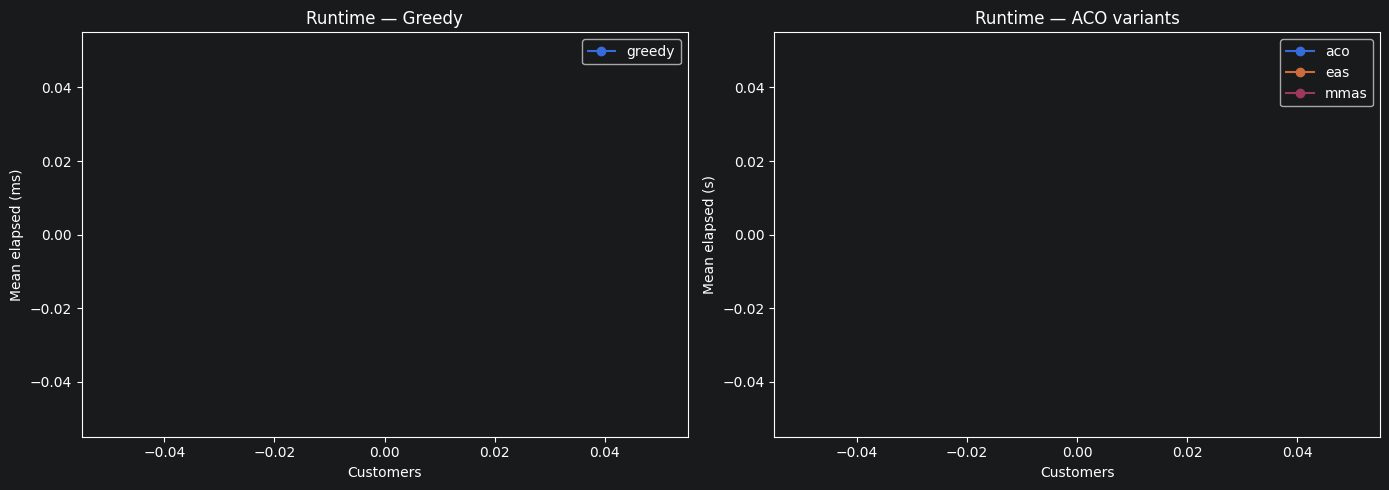

In [5]:
plot_scaling(main)

elapsed = main.groupby(["algorithm", "n_customers"])["elapsed_sec"].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: greedy (ms scale)
g_greedy = elapsed[elapsed["algorithm"] == "greedy"].sort_values("n_customers")
ax1.plot(g_greedy["n_customers"], g_greedy["elapsed_sec"] * 1000, "-o", label="greedy")
ax1.set_xlabel("Customers"); ax1.set_ylabel("Mean elapsed (ms)")
ax1.set_title("Runtime — Greedy"); ax1.legend()

# Right: ACO variants (s scale)
for algo in ["aco", "eas", "mmas"]:
    g = elapsed[elapsed["algorithm"] == algo].sort_values("n_customers")
    ax2.plot(g["n_customers"], g["elapsed_sec"], "-o", label=algo)
ax2.set_xlabel("Customers"); ax2.set_ylabel("Mean elapsed (s)")
ax2.set_title("Runtime — ACO variants"); ax2.legend()
plt.tight_layout()
plt.show()

## H3.3 — Convergence

Full convergence curves and smoothed improvement rate (derivative).

In [6]:
json_files = list(MAIN_DIR.glob("*.json"))
instances = sorted(main["instance"].unique())

for target in instances:
    curves = {}
    for jf in json_files:
        run = json.loads(jf.read_text())
        if (run["instance"] == target and run["seed"] == 42
                and run.get("convergence") and run.get("s_max") is None):
            curves[run["algorithm"]] = run["convergence"]

    aco_curves = {k: v for k, v in curves.items() if k != "greedy"}
    if not aco_curves:
        continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    for algo, curve in aco_curves.items():
        ax1.plot(curve, label=algo)
    ax1.set_xlabel("Iteration"); ax1.set_ylabel("Best distance")
    ax1.set_title(f"{target} — Convergence (seed 42)"); ax1.legend()

    plot_convergence_derivative(aco_curves, f"{target} — Improvement rate", ax=ax2)
    plt.tight_layout()
    plt.show()

# Stagnation summary
from src.metrics import stagnation_length
records = []
for jf in json_files:
    run = json.loads(jf.read_text())
    if not run.get("convergence") or run["algorithm"] == "greedy" or run.get("s_max") is not None:
        continue
    records.append({
        "algorithm": run["algorithm"],
        "instance":  run["instance"],
        "stagnation": stagnation_length(run["convergence"]),
    })
if records:
    conv_df = pd.DataFrame(records)
    display(conv_df.groupby(["algorithm", "instance"])["stagnation"].mean().round(0).unstack())

instance,X-n101-k25,X-n153-k22,X-n200-k36
algorithm,,,
aco,99.0,99.0,99.0
eas,99.0,99.0,99.0
mmas,99.0,99.0,99.0


## H3.4 — S_max & α/β Sensitivity

How tight distance constraints shift the optimal α/β parametrisation.

In [7]:
if SWEEP_DIR.exists() and (SWEEP_DIR / "results.csv").exists():
    sw = pd.read_csv(SWEEP_DIR / "results.csv")
    sw["feasible"] = sw["feasible"].astype(bool)
    sw["relative_error"] = pd.to_numeric(sw["relative_error"], errors="coerce")
    sw["s_max"] = pd.to_numeric(sw["s_max"], errors="coerce")

    # --- Sensitivity tables per S_max level ---
    for s_val in sorted(sw[sw["feasible"]]["s_max"].unique()):
        s_sub = sw[sw["feasible"] & (sw["s_max"] == s_val)]
        if s_sub.empty:
            continue
        label = f"S_max={s_val:.0f}" if not np.isnan(s_val) else "Unconstrained"
        print(f"\n=== {label} — mean total_dist by alpha/beta ===")
        if "param_alpha" in s_sub.columns and "param_beta" in s_sub.columns:
            display(
                s_sub.groupby(["algorithm", "param_alpha", "param_beta"])["total_dist"]
                .agg(["mean", "std", "count"]).round(1).sort_values("mean")
            )

    # --- Dead-end and success rate from JSON ---
    sr_records = []
    for jf in SWEEP_DIR.glob("*.json"):
        run = json.loads(jf.read_text())
        if not run.get("dead_end_ratio"):
            continue
        sr_records.append({
            "algorithm":         run["algorithm"],
            "instance":          run["instance"],
            "s_max":             run.get("s_max"),
            "alpha":             run.get("params", {}).get("alpha"),
            "beta":              run.get("params", {}).get("beta"),
            "mean_dead_ends":    sum(run["dead_end_ratio"]) / len(run["dead_end_ratio"]),
            "mean_success_rate": sum(run["success_rate"]) / len(run["success_rate"]),
        })
    if sr_records:
        sr_df = pd.DataFrame(sr_records)
        print("\n=== Dead-ends & success rate per alpha/beta ===")
        sr_con = sr_df[sr_df["s_max"].notna()]
        if not sr_con.empty:
            display(
                sr_con.groupby(["algorithm", "alpha", "beta"])
                [["mean_dead_ends", "mean_success_rate"]].mean().round(3)
            )

    # --- Route comparison at different S_max levels from JSON ---
    best_by_key = {}
    for jf in SWEEP_DIR.glob("*.json"):
        run = json.loads(jf.read_text())
        if not run.get("feasible") or not run.get("routes"):
            continue
        key = (run["instance"], run["algorithm"], run.get("s_max"))
        if key not in best_by_key or run["total_dist"] < best_by_key[key]["total_dist"]:
            best_by_key[key] = run

    sweep_instances = sorted({k[0] for k in best_by_key})
    sweep_algos = ["greedy", "aco", "eas", "mmas"]

    for inst_name in sweep_instances:
        vrp_path = DATA_DIR / f"{inst_name}.vrp"
        if not vrp_path.exists():
            continue
        inst = load_vrp(str(vrp_path))
        s_max_vals = sorted({k[2] for k in best_by_key if k[0] == inst_name},
                            key=lambda x: x if x is not None else float("inf"))

        n_rows = len(s_max_vals)
        n_cols = len(sweep_algos)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
        for row, s_val in enumerate(s_max_vals):
            for col, algo in enumerate(sweep_algos):
                ax = axes[row, col]
                run = best_by_key.get((inst_name, algo, s_val))
                if run and run.get("routes"):
                    s_label = f"S_max={s_val:.0f}" if s_val is not None else "Unconstrained"
                    plot_routes(run["routes"], inst.coords,
                                f"{algo} — {s_label}\n({run['total_dist']:.0f})", ax=ax)
                else:
                    ax.set_title(f"{algo} — N/A"); ax.axis("off")
        fig.suptitle(f"{inst_name} — Routes by S_max", fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()
else:
    print("Sweep results not found — run sweep experiments first.")

Sweep results not found — run sweep experiments first.
